In [1]:
import os
os.getcwd()

'C:\\Users\\zengo\\TITANIC\\notebooks'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter  #aykırı gözlem için

# Grafikler notebook içinde güzel görünsün
%matplotlib inline

# images klasörü yoksa oluştur
Path("../images").mkdir(exist_ok=True)

In [3]:
train_path = Path("../data/train.csv")
test_path  = Path("../data/test.csv")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.shape

(891, 12)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train_df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [8]:
train_df["Cabin"].head(10)

0     NaN
1     C85
2     NaN
3    C123
4     NaN
5     NaN
6     E46
7     NaN
8     NaN
9     NaN
Name: Cabin, dtype: object

In [9]:
# Cabin kolonunu düşürelim
#train_df = train_df.drop(columns=["Cabin"])

# Age'i median ile dolduralım
#train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())

# Embarked'ı mode ile dolduralım
#train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])

#train_df.isnull().sum()

In [10]:
train_df["Cabin"].value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [11]:
train_df["Cabin"].isnull().mean()

np.float64(0.7710437710437711)

In [12]:
train_df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [13]:
train_df["Age"].median()

28.0

In [14]:
train_df["Age"].mean()

np.float64(29.69911764705882)

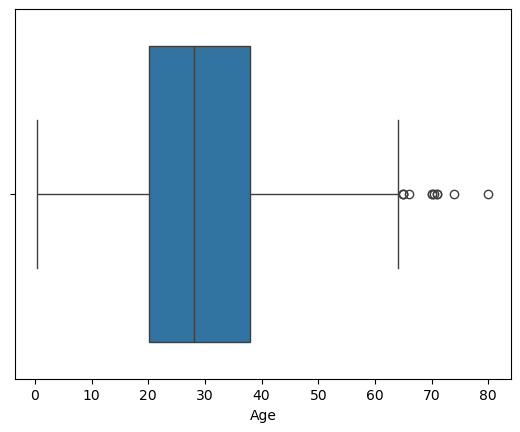

In [15]:
sns.boxplot(x=train_df["Age"])
plt.show()

In [16]:
train_df["Age"].quantile([0.25, 0.5, 0.75])

0.25    20.125
0.50    28.000
0.75    38.000
Name: Age, dtype: float64

In [17]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [18]:
train_df["Survived"].mean()

np.float64(0.3838383838383838)

In [19]:
train_df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [20]:
pd.crosstab(train_df["Pclass"], train_df["Sex"], 
            values=train_df["Survived"], 
            aggfunc="mean")

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [21]:
train_df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [22]:
# Çocuk değişkeni oluşturalım
train_df["IsChild"] = train_df["Age"] <= 12

# Cinsiyet + çocuk durumuna göre survival oranı
pd.crosstab(
    [train_df["IsChild"], train_df["Sex"]],
    train_df["Survived"],
    normalize="index"
)

Survived               0         1
IsChild Sex                       
False   female  0.241135  0.758865
        male    0.837037  0.162963
True    female  0.406250  0.593750
        male    0.432432  0.567568

In [23]:
pd.crosstab(train_df["Pclass"], train_df["IsChild"], normalize="index")

IsChild,False,True
Pclass,,
1,0.981481,0.018519
2,0.907609,0.092391
3,0.902240,0.097760


In [24]:
categorical_cols = train_df.select_dtypes(include=["object"]).columns
categorical_cols

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [25]:
categorical_cols = list(categorical_cols)
categorical_cols.append("Pclass")
categorical_cols

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Pclass']

In [26]:
def category_analysis(col):
    print("------", col, "------")
    print(train_df[col].value_counts())
    sns.countplot(x=train_df[col])
    plt.show()

------ Sex ------
Sex
male      577
female    314
Name: count, dtype: int64


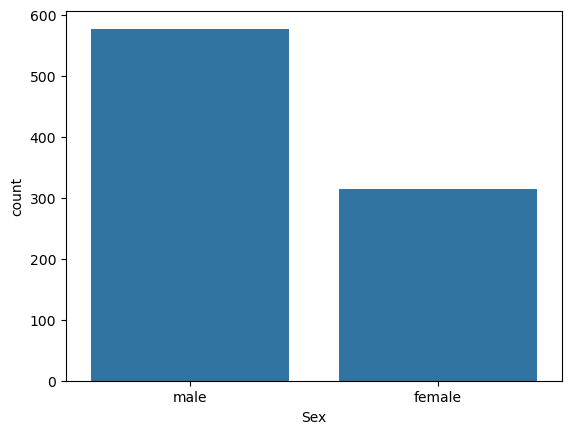

In [27]:
category_analysis("Sex")

------ Pclass ------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


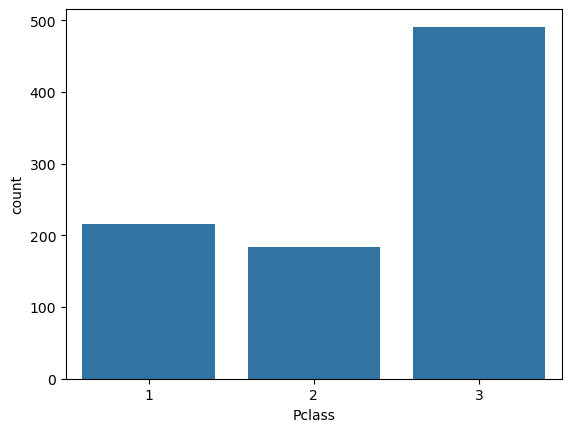

In [28]:
category_analysis("Pclass") #Veri 3. sınıf ağırlıklı. Bu nedenle genel survival oranı 3. sınıfın düşük oranından etkilenmiş olabilir.

------ Embarked ------
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


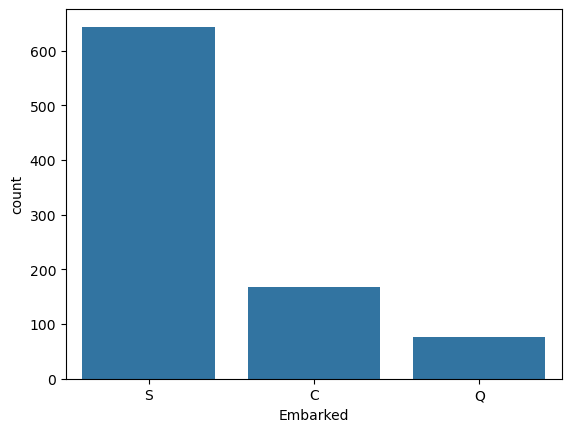

In [29]:
category_analysis("Embarked") #Veri Embarked açısından dengesiz; S limanı baskın. Survival analizi yaparken liman etkisi kontrol edilmeli.

------ SibSp ------
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


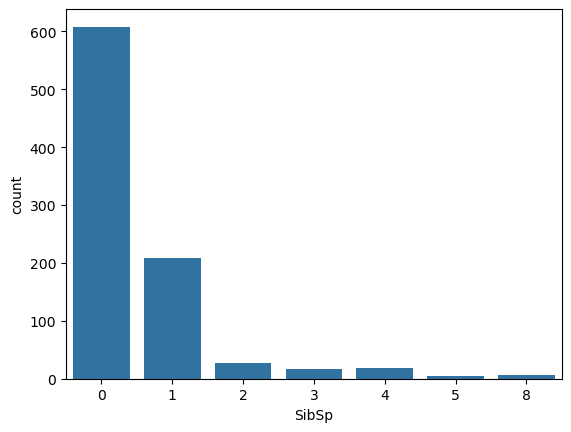

------ Parch ------
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


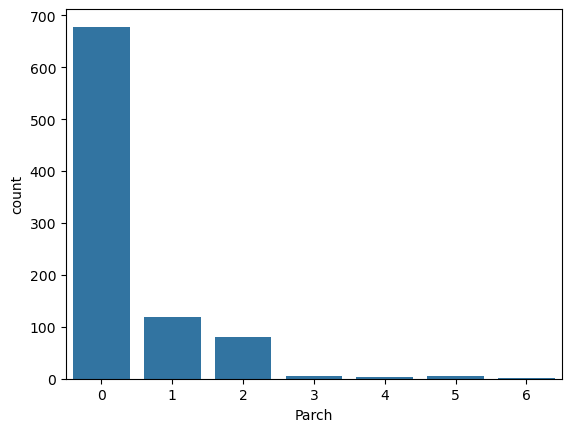

In [30]:
category_analysis("SibSp")
category_analysis("Parch")

In [31]:
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

In [32]:
train_df["FamilySize"].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [33]:
train_df.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [34]:
pd.crosstab(train_df["FamilySize"], train_df["Pclass"], normalize="index")

Pclass,1,2,3
FamilySize,,,
1,0.202980,0.193669,0.603352
2,0.434783,0.211180,0.354037
3,0.235294,0.303922,0.460784
4,0.241379,0.448276,0.310345
5,0.133333,0.066667,0.800000
6,0.181818,0.045455,0.772727
7,0.000000,0.000000,1.000000
8,0.000000,0.000000,1.000000
11,0.000000,0.000000,1.000000


In [35]:
def numerical_analysis(col):
    print("-----", col, "-----")
    print(train_df[col].describe())   # sayısal özet
    plt.hist(train_df[col], bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"{col} Distribution")
    plt.show()

----- Age -----
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


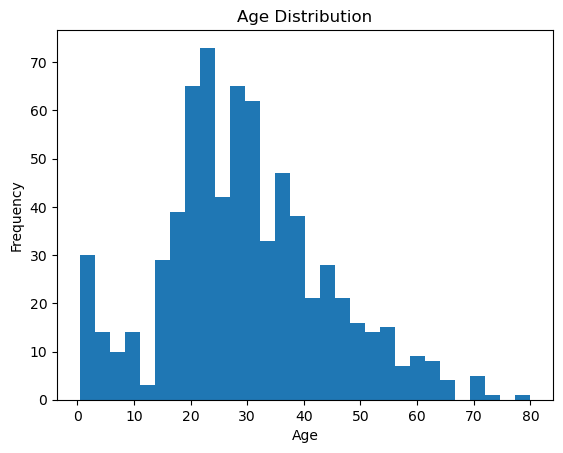

In [36]:
numerical_analysis("Age")

----- Fare -----
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


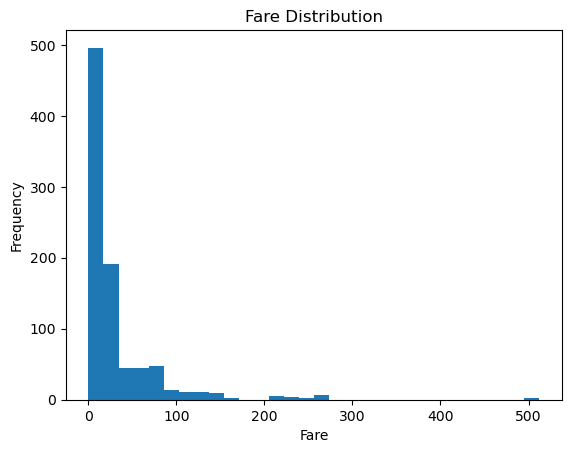

In [37]:
numerical_analysis("Fare")

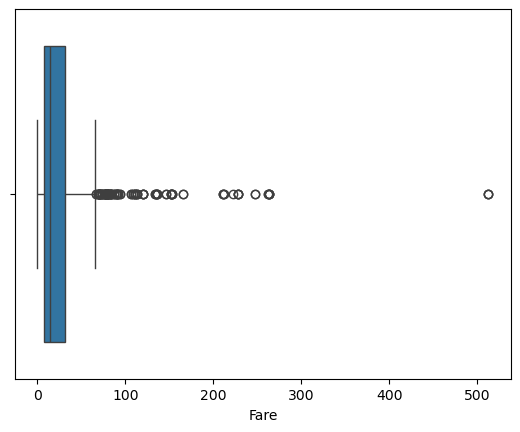

In [38]:
sns.boxplot(x=train_df["Fare"])
plt.show()

In [39]:
train_df.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

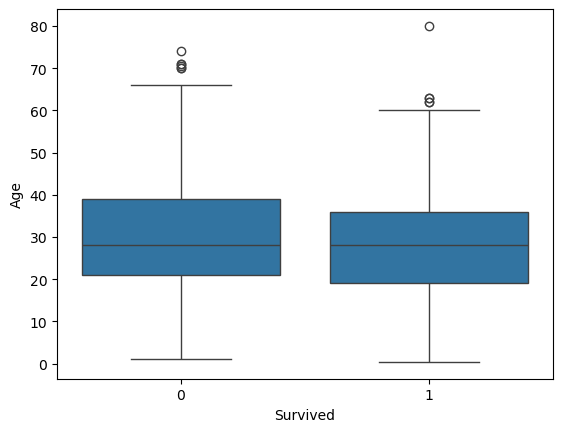

In [40]:
sns.boxplot(x="Survived", y="Age", data=train_df)
plt.show()

In [41]:
train_df.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

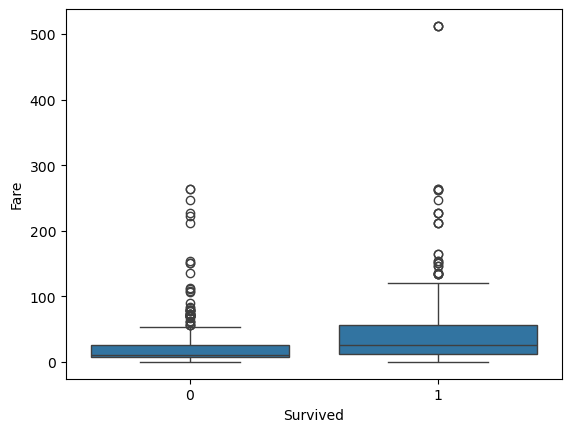

In [42]:
sns.boxplot(x="Survived", y="Fare", data=train_df)
plt.show()

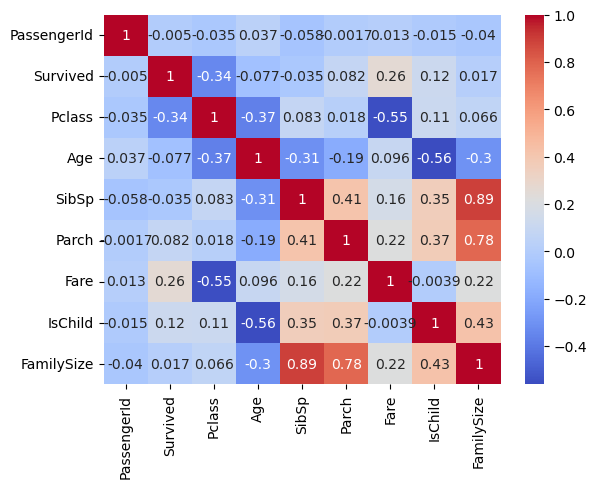

In [43]:
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [44]:
train_df["AgeGroup"] = pd.cut(
    train_df["Age"],
    bins=[0,12,18,40,60,100],
    labels=["Child","Teen","YoungAdult","Adult","Senior"]
)

train_df.groupby("AgeGroup")["Survived"].mean()

C:\Users\zengo\AppData\Local\Temp\ipykernel_17912\3835136865.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby("AgeGroup")["Survived"].mean()


AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.388235
Adult         0.390625
Senior        0.227273
Name: Survived, dtype: float64

In [45]:
pd.crosstab(train_df["AgeGroup"], train_df["Pclass"], normalize="index")

Pclass,1,2,3
AgeGroup,,,
Child,0.057971,0.246377,0.695652
Teen,0.171429,0.171429,0.657143
YoungAdult,0.221176,0.258824,0.520000
Adult,0.484375,0.242188,0.273438
Senior,0.636364,0.136364,0.227273


In [46]:
pd.crosstab(
    [train_df["Pclass"], train_df["Sex"]],
    train_df["Survived"],
    normalize="index"
)

Survived              0         1
Pclass Sex                       
1      female  0.031915  0.968085
       male    0.631148  0.368852
2      female  0.078947  0.921053
       male    0.842593  0.157407
3      female  0.500000  0.500000
       male    0.864553  0.135447

In [47]:
pd.crosstab(
    [train_df["Pclass"], train_df["Sex"], train_df["AgeGroup"]],
    train_df["Survived"],
    normalize="index"
)

Survived                         0         1
Pclass Sex    AgeGroup                      
1      female Child       1.000000  0.000000
              Teen        0.000000  1.000000
              YoungAdult  0.020833  0.979167
              Adult       0.041667  0.958333
              Senior      0.000000  1.000000
       male   Child       0.000000  1.000000
              Teen        0.500000  0.500000
              YoungAdult  0.521739  0.478261
              Adult       0.657895  0.342105
              Senior      0.916667  0.083333
2      female Child       0.000000  1.000000
              Teen        0.000000  1.000000
              YoungAdult  0.085106  0.914894
              Adult       0.153846  0.846154
       male   Child       0.000000  1.000000
              Teen        1.000000  0.000000
              YoungAdult  0.936508  0.063492
              Adult       0.944444  0.055556
              Senior      0.666667  0.333333
3      female Child       0.521739  0.478261
              Teen        0.450000  0.550000
              YoungAdult  0.520000  0.480000
              Adult       1.000000  0.000000
              Senior      0.000000  1.000000
       male   Child       0.640000  0.360000
              Teen        0.923077  0.076923
              YoungAdult  0.853801  0.146199
              Adult       0.925926  0.074074
              Senior      1.000000  0.000000

In [48]:
pd.crosstab(
    [train_df["Pclass"], train_df["Sex"], train_df["AgeGroup"]],
    train_df["Survived"],
)

Survived                    0   1
Pclass Sex    AgeGroup           
1      female Child         1   0
              Teen          0  10
              YoungAdult    1  47
              Adult         1  23
              Senior        0   2
       male   Child         0   3
              Teen          1   1
              YoungAdult   24  22
              Adult        25  13
              Senior       11   1
2      female Child         0   8
              Teen          0   6
              YoungAdult    4  43
              Adult         2  11
       male   Child         0   9
              Teen          6   0
              YoungAdult   59   4
              Adult        17   1
              Senior        2   1
3      female Child        12  11
              Teen          9  11
              YoungAdult   26  24
              Adult         8   0
              Senior        0   1
       male   Child        16   9
              Teen         24   2
              YoungAdult  146  25
              Adult        25   2
              Senior        4   0

In [49]:
train_df.groupby(["Pclass", "Sex", "AgeGroup"]).size().sort_values()

C:\Users\zengo\AppData\Local\Temp\ipykernel_17912\3829162531.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(["Pclass", "Sex", "AgeGroup"]).size().sort_values()


Pclass  Sex     AgeGroup  
2       female  Senior          0
3       female  Senior          1
1       female  Child           1
                Senior          2
        male    Teen            2
                Child           3
2       male    Senior          3
3       male    Senior          4
2       female  Teen            6
        male    Teen            6
        female  Child           8
3       female  Adult           8
2       male    Child           9
1       female  Teen           10
        male    Senior         12
2       female  Adult          13
        male    Adult          18
3       female  Teen           20
                Child          23
1       female  Adult          24
3       male    Child          25
                Teen           26
                Adult          27
1       male    Adult          38
                YoungAdult     46
2       female  YoungAdult     47
1       female  YoungAdult     48
3       female  YoungAdult     50
2       male    Young

In [50]:
train_df.groupby(["Pclass", "Sex", "AgeGroup"]).size().sort_values().head(10)

C:\Users\zengo\AppData\Local\Temp\ipykernel_17912\2889456885.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(["Pclass", "Sex", "AgeGroup"]).size().sort_values().head(10)


Pclass  Sex     AgeGroup
2       female  Senior      0
3       female  Senior      1
1       female  Child       1
                Senior      2
        male    Teen        2
                Child       3
2       male    Senior      3
3       male    Senior      4
2       female  Teen        6
        male    Teen        6
dtype: int64

In [51]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
IsChild          0
FamilySize       0
AgeGroup       177
dtype: int64

In [52]:
train_df = train_df.drop("Cabin", axis=1)

In [53]:
train_df["Embarked"].fillna(train_df["Embarked"].mode()[0], inplace=True)

C:\Users\zengo\AppData\Local\Temp\ipykernel_17912\177627364.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Embarked"].fillna(train_df["Embarked"].mode()[0], inplace=True)


In [54]:
train_df["Embarked"].isnull().sum()

np.int64(0)

In [55]:
#train_df["Age"].fillna(train_df["Age"].median(), inplace=True)

In [56]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
IsChild          0
FamilySize       0
AgeGroup       177
dtype: int64

In [57]:
train_df.groupby("Pclass")["Age"].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [58]:
train_df.groupby("SibSp")["Age"].median()

SibSp
0    29.0
1    30.0
2    23.0
3     9.5
4     6.5
5    11.0
8     NaN
Name: Age, dtype: float64

In [59]:
train_df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [60]:
train_df.groupby("Parch")["Age"].median()


Parch
0    30.0
1    23.0
2    16.5
3    24.0
4    42.5
5    39.0
6    43.0
Name: Age, dtype: float64

In [61]:
train_df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [62]:
train_df.groupby("Sex")["Age"].median()

Sex
female    27.0
male      29.0
Name: Age, dtype: float64

In [63]:
train_df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [64]:
train_df.groupby("Embarked")["Age"].median()

Embarked
C    29.0
Q    27.0
S    28.0
Name: Age, dtype: float64

In [65]:
train_df.groupby(["Pclass","SibSp","Parch"])["Age"].median().head(20)

Pclass  SibSp  Parch
1       0      0        38.5
               1        37.5
               2        22.0
        1      0        36.0
               1        46.0
               2        14.0
               4        64.0
        2      0        50.0
               2        19.5
        3      2        23.0
2       0      0        31.0
               1        26.5
               2        13.0
        1      0        29.5
               1        23.5
               2        24.5
               3        54.0
        2      0        24.0
               1        13.5
               3        24.0
Name: Age, dtype: float64

In [66]:
train_df[train_df["Age"].isnull()][["Pclass","SibSp","Parch"]].median().head(10)

Pclass    3.0
SibSp     0.0
Parch     0.0
dtype: float64

In [67]:
train_df.groupby(["Pclass","SibSp","Parch"])["Age"].median()

Pclass  SibSp  Parch
1       0      0        38.50
               1        37.50
               2        22.00
        1      0        36.00
               1        46.00
               2        14.00
               4        64.00
        2      0        50.00
               2        19.50
        3      2        23.00
2       0      0        31.00
               1        26.50
               2        13.00
        1      0        29.50
               1        23.50
               2        24.50
               3        54.00
        2      0        24.00
               1        13.50
               3        24.00
        3      0        30.00
3       0      0        26.00
               1        18.00
               2        24.00
               3        24.00
               4        29.00
               5        40.00
        1      0        25.00
               1        19.00
               2        13.50
               3        32.00
               4        42.50
               5   

In [68]:
train_df.loc[0]

PassengerId                          1
Survived                             0
Pclass                               3
Name           Braund, Mr. Owen Harris
Sex                               male
Age                               22.0
SibSp                                1
Parch                                0
Ticket                       A/5 21171
Fare                              7.25
Embarked                             S
IsChild                          False
FamilySize                           2
AgeGroup                    YoungAdult
Name: 0, dtype: object

In [69]:
train_df.iloc[0]

PassengerId                          1
Survived                             0
Pclass                               3
Name           Braund, Mr. Owen Harris
Sex                               male
Age                               22.0
SibSp                                1
Parch                                0
Ticket                       A/5 21171
Fare                              7.25
Embarked                             S
IsChild                          False
FamilySize                           2
AgeGroup                    YoungAdult
Name: 0, dtype: object

In [70]:
missing_index = train_df[train_df["Age"].isnull()].index

for i in missing_index:

    pclass = train_df["Pclass"].iloc[i]
    sibsp  = train_df["SibSp"].iloc[i]
    parch  = train_df["Parch"].iloc[i]

    group = train_df[
        (train_df["Pclass"] == pclass) &
        (train_df["SibSp"] == sibsp) &
        (train_df["Parch"] == parch)
    ]

    median_age = group["Age"].median()

    train_df["Age"].iloc[i] = median_age

C:\Users\zengo\AppData\Local\Temp\ipykernel_17912\1848967938.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train_df["Age"].iloc[i] = median_age
C:\Users\zengo\AppData\Local\Temp\ipykernel_17912\1848967938.py:17: SettingWithCopyWarning

In [71]:
train_df.groupby(["Pclass","SibSp","Parch"])["Age"].median().head(10)

Pclass  SibSp  Parch
1       0      0        38.5
               1        37.5
               2        22.0
        1      0        36.0
               1        46.0
               2        14.0
               4        64.0
        2      0        50.0
               2        19.5
        3      2        23.0
Name: Age, dtype: float64

In [72]:
train_df["Age"].isnull().sum()

np.int64(7)

In [73]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              7
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
IsChild          0
FamilySize       0
AgeGroup       177
dtype: int64

In [74]:
train_df["Age"].fillna(train_df["Age"].median(), inplace = True)

C:\Users\zengo\AppData\Local\Temp\ipykernel_17912\170064499.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Age"].fillna(train_df["Age"].median(), inplace = True)


----- Age -----
count    891.000000
mean      29.250471
std       13.324651
min        0.420000
25%       22.000000
50%       26.000000
75%       36.000000
max       80.000000
Name: Age, dtype: float64


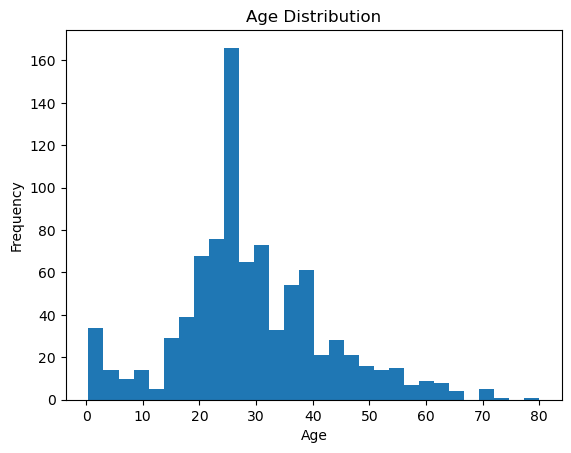

In [75]:
numerical_analysis("Age")

In [76]:
train_df["Age"].isnull().sum()

np.int64(0)

In [77]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.250471,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,13.324651,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


<function matplotlib.pyplot.show(close=None, block=None)>

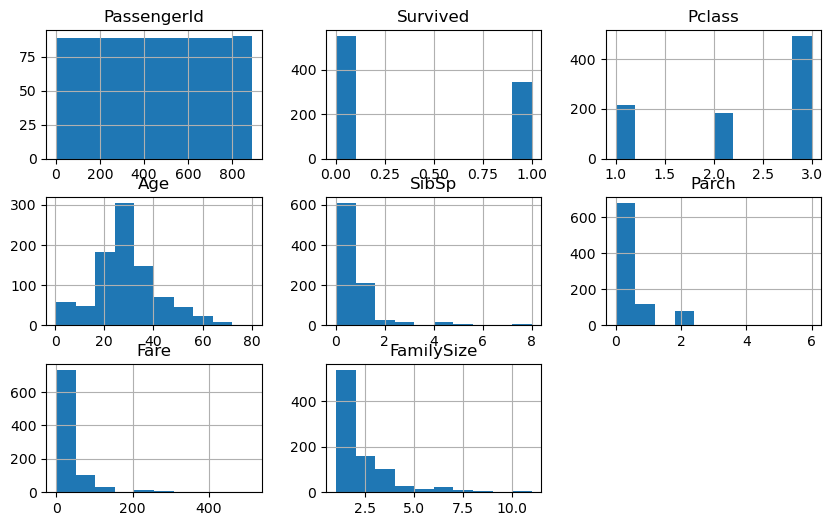

In [78]:
train_df.hist(figsize=(10,6))
plt.show

In [79]:
train_df.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
IsChild            bool
FamilySize        int64
AgeGroup       category
dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

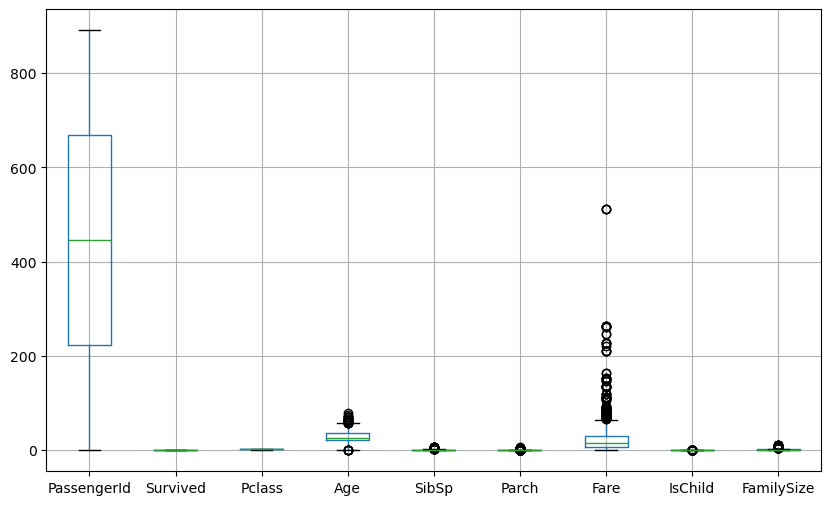

In [80]:
train_df.boxplot(figsize=(10,6))
plt.show

In [81]:
Q1 = train_df["Fare"].quantile(0.25)
Q3 = train_df["Fare"].quantile(0.75)

IQR = Q3 - Q1

alt = Q1 - 1.5 * IQR
ust = Q3 + 1.5 * IQR

train_df[(train_df["Fare"] < alt) | (train_df["Fare"] > ust)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,IsChild,FamilySize,AgeGroup
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,2,YoungAdult
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S,False,6,YoungAdult
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,36.0,1,0,PC 17569,146.5208,C,False,2,NaN
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,C,False,2,YoungAdult
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,C,False,2,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,26.0,8,2,CA. 2343,69.5500,S,False,11,NaN
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,36.0,1,0,17453,89.1042,C,False,2,NaN
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,S,False,3,Adult
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,26.0,8,2,CA. 2343,69.5500,S,False,11,NaN


In [82]:
def outlier_thresholds(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return lower, upper

In [83]:
def check_outlier(df, col):

    lower, upper = outlier_thresholds(df, col)

    return df[(df[col] < lower) | (df[col] > upper)].shape[0] > 0

In [84]:
check_outlier(train_df, "Age")

True

In [85]:
#def check_outlier(df, col):

  #  lower, upper = outlier_thresholds(df, col)

   # if df[(df[col] < lower) | (df[col] > upper)].any().any():
     #   return True
   # else:
     #   return False

In [86]:
def get_outliers(df, col):

    lower, upper = outlier_thresholds(df, col)
    
    return df[(df[col] < lower) | (df[col] > upper)]

In [87]:
 get_outliers(train_df, "Age").shape

(40, 14)

In [88]:
 get_outliers(train_df, "Fare").shape

(116, 14)